# EXIOBASE 3 + pymrio: whole-Sweden hotspot analysis

This notebook adapts the Stockholm prototype to **whole Sweden (`SE`)** without disaggregation.

## What is fixed here

1. **Zero GHG values**
   - In your Stockholm script there were **two plausible failure modes**:
     - the accumulator only summed rows whose names **exactly matched** hard-coded air-emission labels;
     - after rebuilding a modified IO system, `air_emissions.S` could remain zero, so `D_cba = S @ L @ Y` stayed at zero.
   - In this notebook I avoid both issues by:
     - using a **tolerant row matcher** that prints the matched GHG rows and their units;
     - computing `S_manual = F / x` explicitly for the footprint steps.

2. **Readable labels**
   - country codes such as `SE`, `DE`, `WA` are expanded to readable names;
   - sector labels are kept as the readable EXIOBASE sector names returned by `pymrio`.

## Outputs

For **materials**, **GHG**, and **factor inputs** the notebook produces:
- Sweden totals (PBA and CBA)
- top Swedish **PBA sectors**
- top **source sectors** embodied in Sweden's final demand
- top **source countries** embodied in Sweden's final demand
- top **country-sector pairs** embodied in Sweden's final demand
- CSV exports and simple charts

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymrio
from IPython.display import display

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

In [2]:
# =========================
# Configuration
# =========================

EXIOBASE_PATH = Path(r"C:/EXIOBASE3/IOT_2024_pxp.zip")
OUTPUT_DIR = Path("./results_sweden_hotspots")
OUTPUT_DIR.mkdir(exist_ok=True)

SWEDEN_CODE = "SE"
BASE_YEAR = 2024
TOP_N = 15
TOP_PAIR_N = 20

if not EXIOBASE_PATH.exists():
    raise FileNotFoundError(f"EXIOBASE file not found: {EXIOBASE_PATH}")

print(f"EXIOBASE path: {EXIOBASE_PATH}")
print(f"Output dir   : {OUTPUT_DIR.resolve()}")

EXIOBASE path: C:\EXIOBASE3\IOT_2024_pxp.zip
Output dir   : C:\Users\rafaella\OneDrive - RISE\Region Stockholm - Documents\Cirkulär ekonomi\5 Arbetsmaterial och underlag\Dimension_123\results_sweden_hotspots


In [3]:
# =========================
# Load EXIOBASE and compute the system
# =========================

exio = pymrio.parse_exiobase3(path=str(EXIOBASE_PATH))
exio.calc_all()

print(exio.meta)
print()
print(f"Regions : {len(exio.get_regions())}")
print(f"Sectors : {len(exio.get_sectors())}")
print(f"Extensions: {list(exio.get_extensions())}")

Description: EXIOBASE version 3.10.1 - pxp for 2024
MRIO Name: EXIO_IOT_2024_pxp
System: pxp
Version: 3.10.1
File: None
History:
20260415 18:20:34 - MODIFICATION -  Calculating accounts for extension air_emissions
20260415 18:20:23 - MODIFICATION -  Calculating accounts for extension material
20260415 18:20:12 - MODIFICATION -  Calculating accounts for extension factor_inputs
20260415 18:20:02 - MODIFICATION -  Calculating accounts for extension water
20260415 18:19:51 - MODIFICATION -  Calculating accounts for extension nutrients
20260415 18:19:41 - MODIFICATION -  Calculating accounts for extension land
20260415 18:19:41 - MODIFICATION -  Leontief matrix L calculated
20260415 18:19:26 - MODIFICATION -  Coefficient matrix A calculated
20260415 18:19:26 - MODIFICATION -  Changed country names
20260415 18:19:26 - FILEIO -  Added satellite account from air_emissions
 ... (more lines in history)

Regions : 49
Sectors : 200
Extensions: ['land', 'nutrients', 'water', 'factor_inputs', 'mater

## Helper functions

The next cell does four jobs:

1. expands region codes to readable names;
2. safely selects one region from EXIOBASE tables;
3. builds a robust GHG row mapping using **keyword matching instead of exact row names**;
4. computes footprints with `S_manual = F / x`, which avoids relying on a potentially empty `extension.S`.

In [4]:
# =========================
# Readable labels + robust helpers
# =========================

REGION_NAME_MAP = {
    'AT': 'Austria', 'BE': 'Belgium', 'BG': 'Bulgaria', 'CY': 'Cyprus', 'CZ': 'Czechia',
    'DE': 'Germany', 'DK': 'Denmark', 'EE': 'Estonia', 'ES': 'Spain', 'FI': 'Finland',
    'FR': 'France', 'GR': 'Greece', 'HU': 'Hungary', 'IE': 'Ireland', 'IT': 'Italy',
    'LT': 'Lithuania', 'LU': 'Luxembourg', 'LV': 'Latvia', 'MT': 'Malta', 'NL': 'Netherlands',
    'PL': 'Poland', 'PT': 'Portugal', 'RO': 'Romania', 'SE': 'Sweden', 'SI': 'Slovenia',
    'SK': 'Slovakia', 'GB': 'United Kingdom', 'US': 'United States', 'JP': 'Japan',
    'CN': 'China', 'CA': 'Canada', 'KR': 'South Korea', 'BR': 'Brazil', 'IN': 'India',
    'MX': 'Mexico', 'RU': 'Russia', 'AU': 'Australia', 'CH': 'Switzerland', 'TR': 'Türkiye',
    'TW': 'Taiwan', 'NO': 'Norway', 'ID': 'Indonesia', 'ZA': 'South Africa',
    'WA': 'Rest of Asia', 'WL': 'Rest of Latin America', 'WE': 'Rest of Europe',
    'WF': 'Rest of Africa', 'WM': 'Rest of Middle East'
}


def region_name(code: str) -> str:
    return REGION_NAME_MAP.get(code, code)


def pretty_pair(idx) -> str:
    region, sector = idx
    return f"{region_name(region)} — {sector}"


def select_region_columns(df: pd.DataFrame, region_code: str) -> pd.DataFrame:
    if not isinstance(df.columns, pd.MultiIndex):
        raise TypeError('Expected MultiIndex columns (region, sector)')
    mask = df.columns.get_level_values(0) == region_code
    return df.loc[:, mask]


def final_demand_vector(Y: pd.DataFrame, region_code: str) -> pd.Series:
    if not isinstance(Y.columns, pd.MultiIndex):
        raise TypeError('Expected MultiIndex columns in Y (region, final demand category)')
    y = Y.xs(region_code, axis=1, level=0).sum(axis=1)
    y.name = region_code
    return y


def normalize_label(s: str) -> str:
    s = str(s).lower().replace('_', ' ')
    s = re.sub(r'[^a-z0-9]+', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()


def find_rows(index, include=(), exclude=()):
    include = [normalize_label(x) for x in include]
    exclude = [normalize_label(x) for x in exclude]
    out = []
    for label in index:
        norm = normalize_label(label)
        if all(tok in norm for tok in include) and not any(tok in norm for tok in exclude):
            out.append(label)
    return out


def unit_to_kt_factor(unit_value) -> float:
    unit = str(unit_value).lower()
    if 'kg' in unit:
        return 1 / 1e6   # kg -> kt
    if 'ton' in unit or unit.strip() == 't':
        return 1 / 1e3   # t -> kt
    if 'kt' in unit:
        return 1.0       # already kt
    warnings.warn(f"Unclear unit '{unit_value}'. Assuming kg -> kt conversion.")
    return 1 / 1e6


GWP = {
    'CO2': 1,
    'CH4': 28,
    'N2O': 265,
    'SF6': 23500,
    'HFC': 1,   # already CO2-eq in EXIOBASE unit files in the Stockholm script
    'PFC': 1,   # already CO2-eq in EXIOBASE unit files in the Stockholm script
}


def build_ghg_row_mapping(air_ext) -> pd.DataFrame:
    rows = air_ext.F.index
    unit_series = air_ext.unit.squeeze() if hasattr(air_ext, 'unit') else pd.Series(index=rows, dtype=object)
    if isinstance(unit_series, pd.DataFrame):
        unit_series = unit_series.iloc[:, 0]
    unit_series = unit_series.reindex(rows)

    selectors = [
        ('fossil_ghg', 'CO2',  ['co2', 'combustion', 'air'], ['bio']),
        ('fossil_ghg', 'CO2',  ['co2', 'non combustion', 'cement production', 'air'], ['bio']),
        ('fossil_ghg', 'CO2',  ['co2', 'non combustion', 'lime production', 'air'], ['bio']),
        ('fossil_ghg', 'CO2',  ['co2', 'waste', 'fossil', 'air'], ['bio']),

        ('fossil_ghg', 'CH4',  ['ch4', 'combustion', 'air'], ['bio']),
        ('fossil_ghg', 'CH4',  ['ch4', 'non combustion', 'natural gas', 'air'], ['bio']),
        ('fossil_ghg', 'CH4',  ['ch4', 'non combustion', 'crude oil', 'air'], ['bio']),
        ('fossil_ghg', 'CH4',  ['ch4', 'non combustion', 'antracite', 'air'], ['bio']),
        ('fossil_ghg', 'CH4',  ['ch4', 'non combustion', 'bituminous coal', 'air'], ['bio']),
        ('fossil_ghg', 'CH4',  ['ch4', 'non combustion', 'coking coal', 'air'], ['bio']),
        ('fossil_ghg', 'CH4',  ['ch4', 'non combustion', 'lignite', 'air'], ['bio']),
        ('fossil_ghg', 'CH4',  ['ch4', 'non combustion', 'sub bituminous coal', 'air'], ['bio']),
        ('fossil_ghg', 'CH4',  ['ch4', 'non combustion', 'oil refinery', 'air'], ['bio']),
        ('fossil_ghg', 'CH4',  ['ch4', 'agriculture', 'air'], ['bio']),
        ('fossil_ghg', 'CH4',  ['ch4', 'waste', 'air'], ['bio']),

        ('fossil_ghg', 'N2O',  ['n2o', 'combustion', 'air'], ['bio']),
        ('fossil_ghg', 'N2O',  ['n2o', 'agriculture', 'air'], ['bio']),

        ('fossil_ghg', 'SF6',  ['sf6', 'air'], []),
        ('fossil_ghg', 'HFC',  ['hfc', 'air'], []),
        ('fossil_ghg', 'PFC',  ['pfc', 'air'], []),

        ('biogenic_ghg', 'CO2', ['co2', 'bio', 'combustion', 'air'], []),
        ('biogenic_ghg', 'CH4', ['ch4', 'bio', 'combustion', 'air'], []),
        ('biogenic_ghg', 'N2O', ['n2o', 'bio', 'combustion', 'air'], []),
        ('biogenic_ghg', 'CO2', ['co2', 'agriculture', 'peat decay', 'air'], []),
        ('biogenic_ghg', 'CO2', ['co2', 'waste', 'biogenic', 'air'], []),
    ]

    found = []
    for category, gas, include, exclude in selectors:
        matches = find_rows(rows, include=include, exclude=exclude)
        if not matches:
            found.append({
                'category': category, 'gas': gas, 'matched_row': None,
                'unit': None, 'gwp': GWP[gas], 'to_kt_factor': np.nan,
                'keywords': ', '.join(include), 'status': 'NOT FOUND'
            })
        else:
            for match in matches:
                unit_val = unit_series.get(match, '')
                found.append({
                    'category': category, 'gas': gas, 'matched_row': match,
                    'unit': unit_val, 'gwp': GWP[gas], 'to_kt_factor': unit_to_kt_factor(unit_val),
                    'keywords': ', '.join(include), 'status': 'OK'
                })

    mapping = pd.DataFrame(found)
    return mapping


def aggregate_ghg(F_air: pd.DataFrame, air_ext, verbose=False) -> pd.DataFrame:
    mapping = build_ghg_row_mapping(air_ext)
    ok = mapping[mapping['status'] == 'OK'].copy()
    if ok.empty:
        raise ValueError('No GHG rows were matched. Check the row labels in exio.air_emissions.F.index.')

    out = {}
    for category in ['fossil_ghg', 'biogenic_ghg']:
        total = 0
        sub = ok.loc[ok['category'] == category]
        if sub.empty:
            out[category] = pd.Series(0, index=F_air.columns, dtype=float)
            continue
        for _, row in sub.iterrows():
            vals = F_air.loc[row['matched_row']]
            total = total + vals * float(row['gwp']) * float(row['to_kt_factor'])
        out[category] = total

    result = pd.DataFrame(out).T

    if verbose:
        display(mapping)
        missing = mapping[mapping['status'] != 'OK']
        if not missing.empty:
            print('Rows not found (review if these should exist in your EXIOBASE release):')
            display(missing[['category', 'gas', 'keywords', 'status']])
    return result


MATERIAL_CATEGORY_MAP = {
    'biomass': list(range(0, 23)),
    'fossil': list(range(23, 33)),
    'metals': list(range(33, 48)),
    'minerals': list(range(48, 62)),
    'recycled': [],
}


def aggregate_material_categories(F_material: pd.DataFrame) -> pd.DataFrame:
    if F_material.shape[0] < 62:
        raise ValueError(f'Expected at least 62 material rows, got {F_material.shape[0]}')
    out = {}
    for category, idxs in MATERIAL_CATEGORY_MAP.items():
        if len(idxs) == 0:
            out[category] = pd.Series(0, index=F_material.columns, dtype=float)
        else:
            out[category] = F_material.iloc[idxs].sum(axis=0)
    return pd.DataFrame(out).T


def aggregate_factor_inputs(F_factor: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({'total_factor_inputs': F_factor.sum(axis=0)}).T


def manual_S(ext, x_series: pd.Series) -> pd.DataFrame:
    x_safe = x_series.replace(0, np.nan)
    return ext.F.div(x_safe, axis=1).fillna(0)


def footprint_by_origin(ext, y_region: pd.Series, x_series: pd.Series, L: pd.DataFrame) -> pd.DataFrame:
    S = manual_S(ext, x_series)
    M = S @ L
    return M.multiply(y_region, axis=1)


def summarize_by_origin(agg_df: pd.DataFrame):
    # agg_df: impact categories x source (region, sector)
    source_pairs = agg_df.sum(axis=0).sort_values(ascending=False)
    by_country = source_pairs.groupby(level=0).sum().sort_values(ascending=False)
    by_sector = source_pairs.groupby(level=1).sum().sort_values(ascending=False)
    return by_country, by_sector, source_pairs


def domestic_sector_totals(agg_df: pd.DataFrame, region_code: str) -> pd.Series:
    domestic = select_region_columns(agg_df, region_code)
    s = domestic.sum(axis=0)
    return s.groupby(level=1).sum().sort_values(ascending=False)

In [5]:
# =========================
# Diagnostics: inspect the air-emissions row matching
# =========================

print('Example air-emission row names:')
print(exio.air_emissions.F.index[:20].tolist())
print()
print('Matched GHG rows and units used in this notebook:')
_ = aggregate_ghg(exio.air_emissions.F.iloc[:, :5], exio.air_emissions, verbose=True)

Example air-emission row names:
['As - combustion - air', 'B(a)P - combustion - air', 'B(b)F - combustion - air', 'B(k)F - combustion - air', 'CH4 - combustion - air', 'CH4_bio - combustion - air', 'CO - combustion - air', 'CO2 - combustion - air', 'CO2_bio - combustion - air', 'Cd - combustion - air', 'Cr - combustion - air', 'Cu - combustion - air', 'HCB - combustion - air', 'Hg - combustion - air', 'Indeno - combustion - air', 'N2O - combustion - air', 'N2O_bio - combustion - air', 'NH3 - combustion - air', 'NMVOC - combustion - air', 'NOx - combustion - air']

Matched GHG rows and units used in this notebook:


,category,gas,matched_row,unit,gwp,to_kt_factor,keywords,status
0,fossil_ghg,CO2,CO2 - combustion - air,kg,1,0.000001,"co2, combustion, air",OK
1,fossil_ghg,CO2,CO2 - non combustion - Cement production - air,kg,1,0.000001,"co2, combustion, air",OK
2,fossil_ghg,CO2,CO2 - non combustion - Lime production - air,kg,1,0.000001,"co2, combustion, air",OK
3,fossil_ghg,CO2,CO2 - non combustion - Cement production - air,kg,1,0.000001,"co2, non combustion, cement production, air",OK
4,fossil_ghg,CO2,CO2 - non combustion - Lime production - air,kg,1,0.000001,"co2, non combustion, lime production, air",OK
5,fossil_ghg,CO2,CO2 - waste - fossil - air,kg,1,0.000001,"co2, waste, fossil, air",OK
6,fossil_ghg,CH4,CH4 - combustion - air,kg,28,0.000001,"ch4, combustion, air",OK
7,fossil_ghg,CH4,CH4 - non combustion - Extraction/production o...,kg,28,0.000001,"ch4, combustion, air",OK
8,fossil_ghg,CH4,CH4 - non combustion - Extraction/production o...,kg,28,0.000001,"ch4, combustion, air",OK
9,fossil_ghg,CH4,CH4 - non combustion - Mining of antracite - air,kg,28,0.000001,"ch4, combustion, air",OK


If GHG values were zero before, this diagnostic cell is the place to look first.

- If the `status` column shows many **NOT FOUND** rows, then the previous exact-name lookup was too strict.
- If the row matching looks fine but `extension.S` is still suspicious, the footprint code below does **not** rely on `extension.S`; it recomputes `S_manual = F / x` directly.

In [6]:
# =========================
# Sweden final demand vector and common objects
# =========================

x_series = exio.x.squeeze()
y_se = final_demand_vector(exio.Y, SWEDEN_CODE)

print(f'Total Sweden final demand vector length: {len(y_se):,}')
print(f'Total Sweden final demand (sum): {y_se.sum():,.3f}')

Total Sweden final demand vector length: 9,800
Total Sweden final demand (sum): 537,934.439


In [8]:
# =========================
# 1) Materials
# =========================

mat_pba_df = aggregate_material_categories(select_region_columns(exio.material.F, SWEDEN_CODE))
mat_pba_totals = mat_pba_df.sum(axis=1).rename('PBA_Sweden')
mat_pba_top_sectors = domestic_sector_totals(mat_pba_df, SWEDEN_CODE)

mat_fp = footprint_by_origin(exio.material, y_se, x_series, exio.L)
mat_cba_df = aggregate_material_categories(mat_fp)
mat_cba_totals = mat_cba_df.sum(axis=1).rename('CBA_Sweden')
mat_countries, mat_sectors, mat_pairs = summarize_by_origin(mat_cba_df)

material_summary = pd.concat([mat_pba_totals, mat_cba_totals], axis=1)
material_summary['Net_PBA_minus_CBA'] = material_summary['PBA_Sweden'] - material_summary['CBA_Sweden']

print('Material summary (Sweden):')
display(material_summary)
print('Top Swedish material PBA sectors:')
display(mat_pba_top_sectors.head(TOP_N).to_frame('kt'))
print('Top source countries in Sweden material footprint:')
display(mat_countries.head(TOP_N).rename(index=region_name).to_frame('kt'))
print('Top source sectors in Sweden material footprint:')
display(mat_sectors.head(TOP_N).to_frame('kt'))

Material summary (Sweden):


,PBA_Sweden,CBA_Sweden,Net_PBA_minus_CBA
biomass,64371.562672,56723.595290,7647.967382
fossil,200.942609,23881.000873,-23680.058264
metals,85279.541394,33525.461551,51754.079843
minerals,128672.715597,160749.611544,-32076.895947
recycled,0.000000,0.000000,0.000000


Top Swedish material PBA sectors:


,kt
sector,
Sand and clay,122575.241830
Iron ores,44252.629460
"Products of forestry, logging and related services (02)",42530.261822
Copper ores and concentrates,26748.719274
Precious metal ores and concentrates,10459.636192
Cattle,7216.828360
Stone,6074.014678
"Lead, zinc and tin ores and concentrates",3769.924656
Wheat,3098.352459


Top source countries in Sweden material footprint:


,kt
region,
Sweden,194085.899208
Rest of Asia,10338.128518
China,9244.903059
Germany,6111.699897
Poland,5424.885372
Norway,5327.770563
Denmark,4877.956749
United States,2984.555755
Netherlands,2877.363043


Top source sectors in Sweden material footprint:


,kt
sector,
Construction work (45),98092.271657
Precious metal ores and concentrates,23100.553768
Food products nec,12670.326253
Products of meat cattle,7352.273912
"Motor vehicles, trailers and semi-trailers (34)",6985.453600
Hotel and restaurant services (55),6954.924828
Health and social work services (85),6106.230717
Public administration and defence services; compulsory social security services (75),5803.251104
Education services (80),5799.528545


In [10]:
# =========================
# 2) GHG (robust matching + explicit unit handling)
# =========================

ghg_pba_df = aggregate_ghg(select_region_columns(exio.air_emissions.F, SWEDEN_CODE), exio.air_emissions, verbose=False)
ghg_pba_totals = ghg_pba_df.sum(axis=1).rename('PBA_Sweden_ktCO2e')
ghg_pba_top_sectors = domestic_sector_totals(ghg_pba_df, SWEDEN_CODE)

ghg_fp = footprint_by_origin(exio.air_emissions, y_se, x_series, exio.L)
ghg_cba_df = aggregate_ghg(ghg_fp, exio.air_emissions, verbose=False)
ghg_cba_totals = ghg_cba_df.sum(axis=1).rename('CBA_Sweden_ktCO2e')
ghg_countries, ghg_sectors, ghg_pairs = summarize_by_origin(ghg_cba_df)

ghg_summary = pd.concat([ghg_pba_totals, ghg_cba_totals], axis=1)
ghg_summary['Net_PBA_minus_CBA'] = ghg_summary.iloc[:, 0] - ghg_summary.iloc[:, 1]

print('GHG summary (Sweden):')
display(ghg_summary)
print('Top Swedish GHG PBA sectors:')
display(ghg_pba_top_sectors.head(TOP_N).to_frame('kt CO2e'))
print('Top source countries in Sweden GHG footprint:')
display(ghg_countries.head(TOP_N).rename(index=region_name).to_frame('kt CO2e'))
print('Top source sectors in Sweden GHG footprint:')
display(ghg_sectors.head(TOP_N).to_frame('kt CO2e'))

GHG summary (Sweden):


,PBA_Sweden_ktCO2e,CBA_Sweden_ktCO2e,Net_PBA_minus_CBA
fossil_ghg,26772.451913,792433.679874,-765661.227961
biogenic_ghg,427.943564,8068.335202,-7640.391638


Top Swedish GHG PBA sectors:


,kt CO2e
sector,
Paper for treatment: landfill,6245.778126
Food waste for treatment: landfill,5955.944382
Raw milk,3910.113587
"Cement, lime and plaster",2499.634718
Cattle,2421.422914
Cereal grains nec,1103.633429
Wheat,581.966615
Plastic waste for treatment: landfill,478.944512
Oil seeds,261.564925


Top source countries in Sweden GHG footprint:


,kt CO2e
region,
Sweden,322531.464060
Switzerland,287167.956237
Germany,46560.061688
Italy,15124.720169
Netherlands,14814.533960
Denmark,12522.675464
France,12146.709485
Ireland,9159.979196
Rest of Asia,7922.981790


Top source sectors in Sweden GHG footprint:


,kt CO2e
sector,
Hotel and restaurant services (55),117985.660858
Dairy products,109901.096240
"Retail trade services, except of motor vehicles and motorcycles; repair services of personal and household goods (52)",57992.874472
Food products nec,55768.518008
Public administration and defence services; compulsory social security services (75),47399.014600
Construction work (45),47025.043567
Computer and related services (72),32318.578851
Education services (80),31231.714505
Health and social work services (85),27332.680541


In [11]:
# =========================
# 3) Factor inputs (economic value)
# =========================

factor_pba_df = aggregate_factor_inputs(select_region_columns(exio.factor_inputs.F, SWEDEN_CODE))
factor_pba_totals = factor_pba_df.sum(axis=1).rename('PBA_Sweden')
factor_pba_top_sectors = domestic_sector_totals(factor_pba_df, SWEDEN_CODE)

factor_fp = footprint_by_origin(exio.factor_inputs, y_se, x_series, exio.L)
factor_cba_df = aggregate_factor_inputs(factor_fp)
factor_cba_totals = factor_cba_df.sum(axis=1).rename('CBA_Sweden')
factor_countries, factor_sectors, factor_pairs = summarize_by_origin(factor_cba_df)

factor_summary = pd.concat([factor_pba_totals, factor_cba_totals], axis=1)
factor_summary['Net_PBA_minus_CBA'] = factor_summary.iloc[:, 0] - factor_summary.iloc[:, 1]

factor_unit = None
if hasattr(exio.factor_inputs, 'unit'):
    fu = exio.factor_inputs.unit
    if isinstance(fu, pd.DataFrame):
        factor_unit = fu.iloc[0, 0]
    elif isinstance(fu, pd.Series) and len(fu) > 0:
        factor_unit = fu.iloc[0]

print(f'Factor-input unit (first row): {factor_unit}')
print('Factor-input summary (Sweden):')
display(factor_summary)
print('Top Swedish factor-input PBA sectors:')
display(factor_pba_top_sectors.head(TOP_N).to_frame(str(factor_unit)))
print('Top source countries in Sweden factor-input footprint:')
display(factor_countries.head(TOP_N).rename(index=region_name).to_frame(str(factor_unit)))
print('Top source sectors in Sweden factor-input footprint:')
display(factor_sectors.head(TOP_N).to_frame(str(factor_unit)))

Factor-input unit (first row): M.EUR
Factor-input summary (Sweden):


,PBA_Sweden,CBA_Sweden,Net_PBA_minus_CBA
total_factor_inputs,561536.969934,537934.438686,23602.531248


Top Swedish factor-input PBA sectors:


,M.EUR
sector,
Other business services (74),43512.655769
Other land transportation services,41714.192327
Health and social work services (85),41549.748051
Computer and related services (72),38792.172387
Construction work (45),36702.379088
Education services (80),28119.788818
"Wholesale trade and commission trade services, except of motor vehicles and motorcycles (51)",24119.161945
Public administration and defence services; compulsory social security services (75),22277.396242
Machinery and equipment n.e.c. (29),21778.644437


Top source countries in Sweden factor-input footprint:


,M.EUR
region,
Sweden,419115.015288
Germany,17007.507555
Denmark,11235.608736
Norway,6874.457036
Rest of Asia,5976.209844
United States,5627.420597
Netherlands,5468.150712
United Kingdom,5248.534455
China,4979.737995


Top source sectors in Sweden factor-input footprint:


,M.EUR
sector,
Construction work (45),78459.545212
Health and social work services (85),52752.347422
Education services (80),44026.657117
Computer and related services (72),37398.323860
Public administration and defence services; compulsory social security services (75),31643.410611
"Retail trade services, except of motor vehicles and motorcycles; repair services of personal and household goods (52)",22002.959765
Food products nec,19209.546818
Air transport services (62),18452.202807
Machinery and equipment n.e.c. (29),17742.303825


In [12]:
# =========================
# Top country-sector pairs (whole Sweden)
# =========================

material_pairs_pretty = mat_pairs.head(TOP_PAIR_N).to_frame('kt')
material_pairs_pretty['source'] = [pretty_pair(idx) for idx in material_pairs_pretty.index]
material_pairs_pretty = material_pairs_pretty[['source', 'kt']]

ghg_pairs_pretty = ghg_pairs.head(TOP_PAIR_N).to_frame('kt CO2e')
ghg_pairs_pretty['source'] = [pretty_pair(idx) for idx in ghg_pairs_pretty.index]
ghg_pairs_pretty = ghg_pairs_pretty[['source', 'kt CO2e']]

factor_pairs_pretty = factor_pairs.head(TOP_PAIR_N).to_frame(str(factor_unit))
factor_pairs_pretty['source'] = [pretty_pair(idx) for idx in factor_pairs_pretty.index]
factor_pairs_pretty = factor_pairs_pretty[['source', str(factor_unit)]]

print('Top material country-sector pairs embodied in Sweden final demand:')
display(material_pairs_pretty)
print('Top GHG country-sector pairs embodied in Sweden final demand:')
display(ghg_pairs_pretty)
print('Top factor-input country-sector pairs embodied in Sweden final demand:')
display(factor_pairs_pretty)

Top material country-sector pairs embodied in Sweden final demand:


source            kt
region sector                                                                                                             
SE     Construction work (45)                                                Sweden — Construction work (45)  94230.446822
       Precious metal ores and concentrates                    Sweden — Precious metal ores and concentrates  23100.553768
       Food products nec                                                          Sweden — Food products nec   6392.751674
       Health and social work services (85)                    Sweden — Health and social work services (85)   5637.164119
       Education services (80)                                              Sweden — Education services (80)   5567.568973
       Public administration and defence services; com...  Sweden — Public administration and defence ser...   5180.781928
       Products of meat cattle                                              Sweden — Products of meat cattle   4943.490293
       Retail  trade services, except of motor vehicle...  Sweden — Retail  trade services, except of mot...   3224.577207
       Dairy products                                                                Sweden — Dairy products   3074.873485
       Computer and related services (72)                        Sweden — Computer and related services (72)   3056.308536
       Products of forestry, logging and related servi...  Sweden — Products of forestry, logging and rel...   2828.783643
       Lead, zinc and tin ores and concentrates            Sweden — Lead, zinc and tin ores and concentrates   2582.076398
WA     Wearing apparel; furs (18)                                  Rest of Asia — Wearing apparel; furs (18)   2261.021329
SE     Wholesale trade and commission trade services, ...  Sweden — Wholesale trade and commission trade ...   2192.803890
WA     Hotel and restaurant services (55)                  Rest of Asia — Hotel and restaurant services (55)   1951.111040
SE     Gas/Diesel Oil                                                                Sweden — Gas/Diesel Oil   1904.034199
       Plastics, basic                                                              Sweden — Plastics, basic   1828.025901
       Machinery and equipment n.e.c. (29)                      Sweden — Machinery and equipment n.e.c. (29)   1639.478201
       Sea and coastal water transportation services       Sweden — Sea and coastal water transportation ...   1580.157353
       Renting services of machinery and equipment wit...  Sweden — Renting services of machinery and equ...   1548.796861

Top GHG country-sector pairs embodied in Sweden final demand:


source       kt CO2e
region sector                                                                                                             
CH     Hotel and restaurant services (55)                   Switzerland — Hotel and restaurant services (55)  85058.388203
       Dairy products                                                           Switzerland — Dairy products  54878.513553
SE     Retail  trade services, except of motor vehicle...  Sweden — Retail  trade services, except of mot...  45243.326405
       Construction work (45)                                                Sweden — Construction work (45)  42673.818344
       Education services (80)                                              Sweden — Education services (80)  29190.555320
CH     Public administration and defence services; com...  Switzerland — Public administration and defenc...  28714.609765
SE     Dairy products                                                                Sweden — Dairy products  25505.750212
CH     Food products nec                                                     Switzerland — Food products nec  25268.080915
SE     Health and social work services (85)                    Sweden — Health and social work services (85)  24072.918653
       Computer and related services (72)                        Sweden — Computer and related services (72)  21679.396527
       Wholesale trade and commission trade services, ...  Sweden — Wholesale trade and commission trade ...  19398.324460
       Public administration and defence services; com...  Sweden — Public administration and defence ser...  17956.015271
CH     Wearing apparel; furs (18)                                   Switzerland — Wearing apparel; furs (18)  12397.644777
       Retail  trade services, except of motor vehicle...  Switzerland — Retail  trade services, except o...  12195.378849
DE     Dairy products                                                               Germany — Dairy products  11580.496330
CH     Textiles (17)                                                             Switzerland — Textiles (17)   9065.365792
       Post and telecommunication services (64)            Switzerland — Post and telecommunication servi...   9060.758666
SE     Food products nec                                                          Sweden — Food products nec   8951.185418
DE     Hotel and restaurant services (55)                       Germany — Hotel and restaurant services (55)   8669.726493
SE     Renting services of machinery and equipment wit...  Sweden — Renting services of machinery and equ...   8573.642229

Top factor-input country-sector pairs embodied in Sweden final demand:


source         M.EUR
region sector                                                                                                             
SE     Construction work (45)                                                Sweden — Construction work (45)  75368.346509
       Health and social work services (85)                    Sweden — Health and social work services (85)  51375.019601
       Education services (80)                                              Sweden — Education services (80)  43249.683978
       Computer and related services (72)                        Sweden — Computer and related services (72)  32520.629488
       Public administration and defence services; com...  Sweden — Public administration and defence ser...  30697.370777
       Retail  trade services, except of motor vehicle...  Sweden — Retail  trade services, except of mot...  21339.429951
       Wholesale trade and commission trade services, ...  Sweden — Wholesale trade and commission trade ...  15054.782794
       Air transport services (62)                                      Sweden — Air transport services (62)  14889.700378
       Financial intermediation services, except insur...  Sweden — Financial intermediation services, ex...  14757.582129
       Food products nec                                                          Sweden — Food products nec  11377.272386
       Renting services of machinery and equipment wit...  Sweden — Renting services of machinery and equ...  10723.778186
       Insurance and pension funding services, except ...  Sweden — Insurance and pension funding service...   7800.215725
       Membership organisation services n.e.c. (91)        Sweden — Membership organisation services n.e....   7583.457122
       Machinery and equipment n.e.c. (29)                      Sweden — Machinery and equipment n.e.c. (29)   6764.222481
       Distribution and trade services of electricity      Sweden — Distribution and trade services of el...   6735.806589
       Other services (93)                                                      Sweden — Other services (93)   6193.693772
       Sea and coastal water transportation services       Sweden — Sea and coastal water transportation ...   6173.531647
       Plastics, basic                                                              Sweden — Plastics, basic   5878.346789
DE     Motor vehicles, trailers and semi-trailers (34)     Germany — Motor vehicles, trailers and semi-tr...   5330.716352
SE     Other business services (74)                                    Sweden — Other business services (74)   5056.529372

In [13]:
# =========================
# Save outputs to CSV
# =========================

material_summary.to_csv(OUTPUT_DIR / 'sweden_material_summary.csv')
ghg_summary.to_csv(OUTPUT_DIR / 'sweden_ghg_summary.csv')
factor_summary.to_csv(OUTPUT_DIR / 'sweden_factor_summary.csv')

mat_pba_top_sectors.head(TOP_N).to_frame('kt').to_csv(OUTPUT_DIR / 'sweden_material_top_pba_sectors.csv')
mat_countries.head(TOP_N).rename(index=region_name).to_frame('kt').to_csv(OUTPUT_DIR / 'sweden_material_top_source_countries.csv')
mat_sectors.head(TOP_N).to_frame('kt').to_csv(OUTPUT_DIR / 'sweden_material_top_source_sectors.csv')
material_pairs_pretty.to_csv(OUTPUT_DIR / 'sweden_material_top_country_sector_pairs.csv', index=False)

ghg_pba_top_sectors.head(TOP_N).to_frame('kt CO2e').to_csv(OUTPUT_DIR / 'sweden_ghg_top_pba_sectors.csv')
ghg_countries.head(TOP_N).rename(index=region_name).to_frame('kt CO2e').to_csv(OUTPUT_DIR / 'sweden_ghg_top_source_countries.csv')
ghg_sectors.head(TOP_N).to_frame('kt CO2e').to_csv(OUTPUT_DIR / 'sweden_ghg_top_source_sectors.csv')
ghg_pairs_pretty.to_csv(OUTPUT_DIR / 'sweden_ghg_top_country_sector_pairs.csv', index=False)

factor_pba_top_sectors.head(TOP_N).to_frame(str(factor_unit)).to_csv(OUTPUT_DIR / 'sweden_factor_top_pba_sectors.csv')
factor_countries.head(TOP_N).rename(index=region_name).to_frame(str(factor_unit)).to_csv(OUTPUT_DIR / 'sweden_factor_top_source_countries.csv')
factor_sectors.head(TOP_N).to_frame(str(factor_unit)).to_csv(OUTPUT_DIR / 'sweden_factor_top_source_sectors.csv')
factor_pairs_pretty.to_csv(OUTPUT_DIR / 'sweden_factor_top_country_sector_pairs.csv', index=False)

print(f'CSV files written to: {OUTPUT_DIR.resolve()}')

CSV files written to: C:\Users\rafaella\OneDrive - RISE\Region Stockholm - Documents\Cirkulär ekonomi\5 Arbetsmaterial och underlag\Dimension_123\results_sweden_hotspots


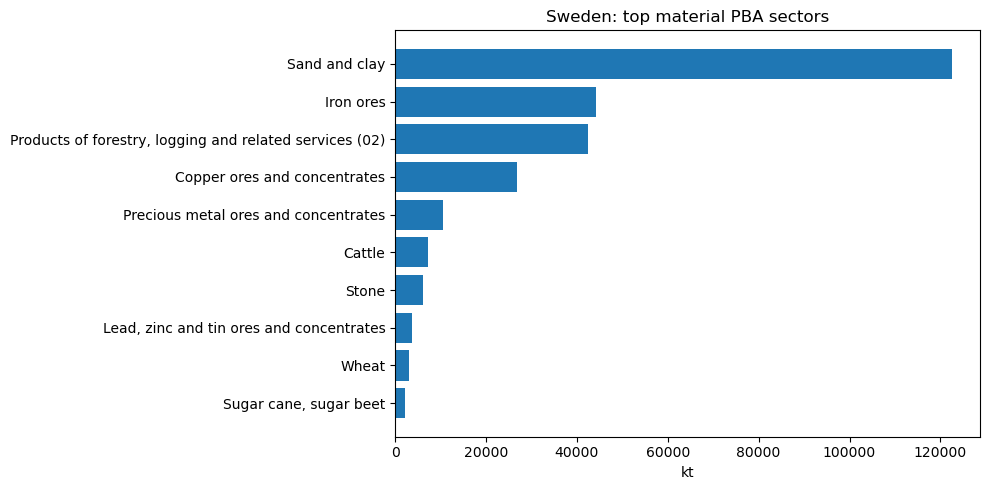

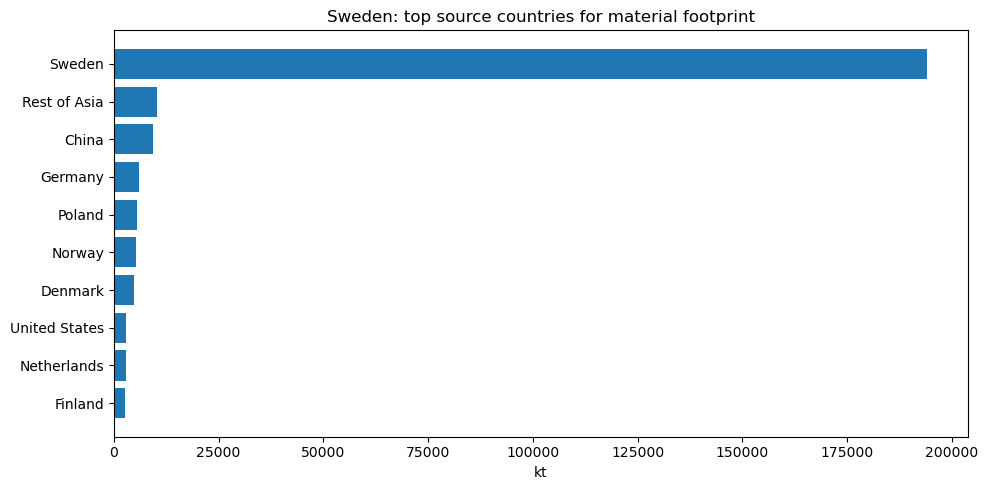

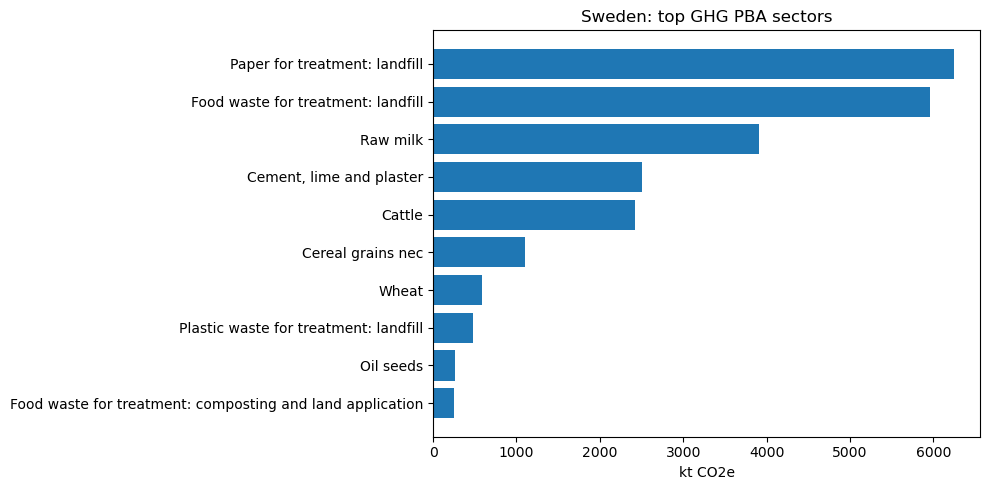

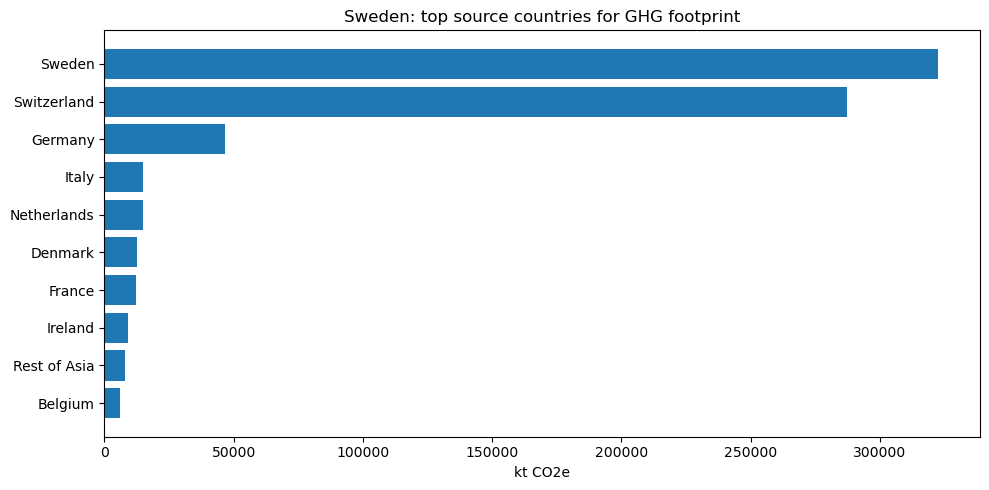

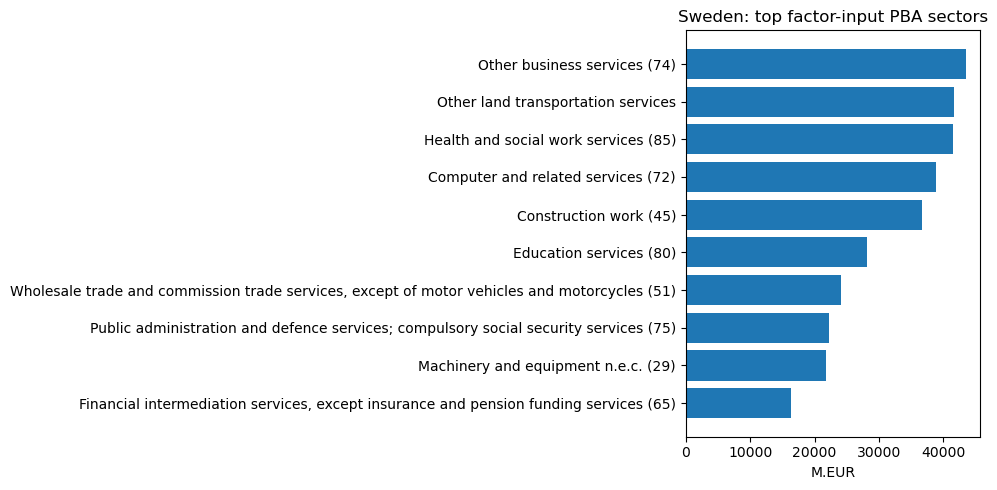

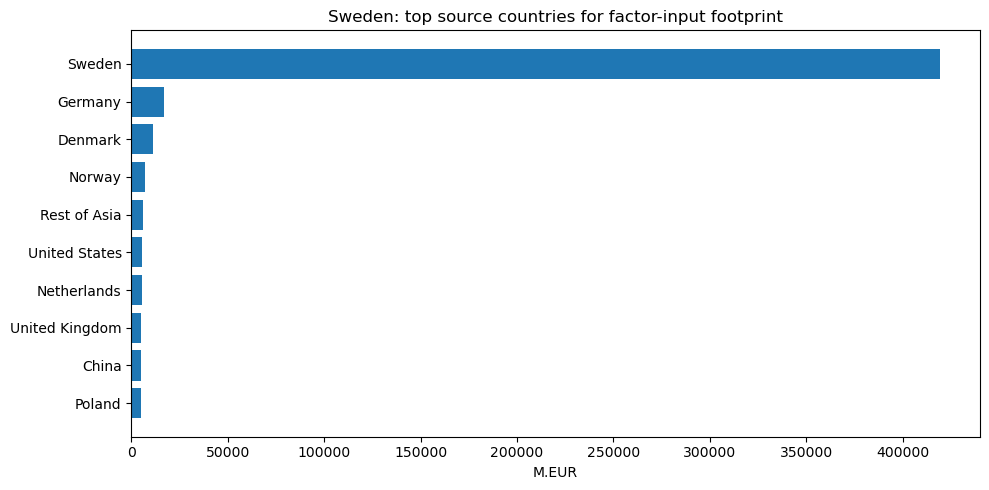

In [14]:
# =========================
# Simple charts
# =========================

def barh_plot(series, title, xlabel, filename, top_n=10):
    s = series.head(top_n).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(s.index.astype(str), s.values)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()

barh_plot(mat_pba_top_sectors, 'Sweden: top material PBA sectors', 'kt', 'chart_material_pba_sectors.png')
barh_plot(mat_countries.rename(index=region_name), 'Sweden: top source countries for material footprint', 'kt', 'chart_material_source_countries.png')
barh_plot(ghg_pba_top_sectors, 'Sweden: top GHG PBA sectors', 'kt CO2e', 'chart_ghg_pba_sectors.png')
barh_plot(ghg_countries.rename(index=region_name), 'Sweden: top source countries for GHG footprint', 'kt CO2e', 'chart_ghg_source_countries.png')
barh_plot(factor_pba_top_sectors, 'Sweden: top factor-input PBA sectors', str(factor_unit), 'chart_factor_pba_sectors.png')
barh_plot(factor_countries.rename(index=region_name), 'Sweden: top source countries for factor-input footprint', str(factor_unit), 'chart_factor_source_countries.png')

## Notes

- `exio.get_sectors()` already returns readable EXIOBASE sector names in `pymrio`, so sector labels should already be human-readable.
- Country labels are expanded with the `REGION_NAME_MAP` dictionary.
- The GHG calculation is deliberately transparent: the notebook prints the matched rows and units so you can see **exactly** which air-emission rows are being aggregated.
- For the Sweden-wide analysis there is no country split, so the whole notebook is much simpler than the Stockholm prototype.